## **PRACTICAL 3**

# Face Recognition Using PCA (Eigenfaces)

This project involves analyzing human face images using Principal Component Analysis (PCA).

### What we will do:
- Load a dataset of grayscale human face images.
- Preprocess the images by resizing and flattening them for uniformity.
- Apply PCA to extract the most important features (called eigenfaces) from the dataset.
- Use these eigenfaces to reconstruct a new face image (a selfie).
- Compare the original and reconstructed images to understand how well PCA captures facial features.


# **PART 1**

## Step 1: Download and Load the LFW Face Dataset

Instead of manually downloading files, we will use a built-in dataset called **Labeled Faces in the Wild (LFW)** from scikit-learn. This dataset contains hundreds of face images, suitable for our experiments.

We will:
- Automatically download the dataset.
- Convert images to grayscale and resize to 32x32 pixels.
- Prepare the images matrix for PCA.

To reduce waiting time, we select people with at least 70 images, so fewer face images are downloaded and processed. This will speed up preprocessing while keeping enough data for PCA.

In [ ]:
import shutil
from sklearn.datasets import get_data_home

cache_dir = get_data_home()
lfw_cache_dir = f"{cache_dir}/lfw_home"
shutil.rmtree(lfw_cache_dir, ignore_errors=True)
print("Cleared LFW dataset cache. Please rerun the data loading cell.")


Cleared LFW dataset cache. Please rerun the data loading cell.


In [ ]:
from sklearn.datasets import fetch_lfw_people
import numpy as np
from PIL import Image

def load_lfw_small(target_size=(32, 32), min_faces_per_person=70):
    """
    Load a smaller version of the LFW dataset filtered by
    minimum faces per person, convert images to target size, flatten them.

    Parameters:
    - target_size: final image size (width, height)
    - min_faces_per_person: minimum images for a person to be included

    Returns:
    - faces_matrix: matrix of N x (width*height)
    """
    lfw = fetch_lfw_people(min_faces_per_person=min_faces_per_person, color=False)
    images = lfw.images  # grayscale images

    image_vectors = []
    for img in images:
        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        resized_img = pil_img.resize(target_size)
        vector = np.array(resized_img).flatten()
        image_vectors.append(vector)

    faces_matrix = np.vstack(image_vectors)
    return faces_matrix

faces_matrix = load_lfw_small()
print(f"Loaded dataset shape: {faces_matrix.shape}")  # Should be around (N, 1024)


Loaded dataset shape: (1288, 1024)


## Visualizing Sample Faces from the Loaded Dataset

The dataset contains 1288 images, each resized and flattened into 1024-length vectors.

Below are 5 example face images reshaped back to 32×32 pixels so you can see what the data looks like visually.


Dataset shape: (1288, 1024)


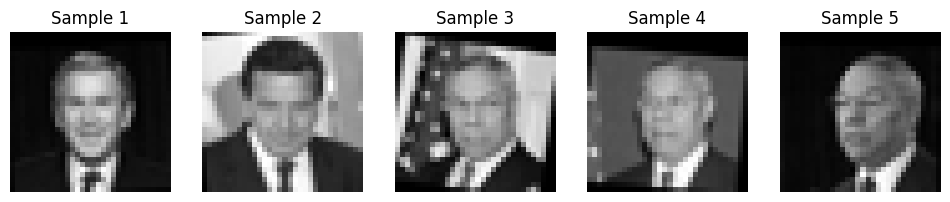

In [ ]:
import matplotlib.pyplot as plt

# Confirm dataset shape
print(f"Dataset shape: {faces_matrix.shape}")

# Select 5 random samples to display
num_samples = 5
sample_indices = np.random.choice(faces_matrix.shape[0], num_samples, replace=False)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(sample_indices):
    img = faces_matrix[idx].reshape(32, 32)
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Sample {i+1}")
    plt.axis('off')
plt.show()


## Step 2: Principal Component Analysis (PCA) for Faces

Principal Component Analysis (PCA) is a mathematical tool used to reduce the number of features in data, while keeping the most important information.

- For face images, PCA allows us to find special "basis images" called *eigenfaces*. These are the main patterns or features that describe faces in the dataset.
- By keeping only the eigenfaces that explain most of the original variance (in this case, 95%), we can represent faces more efficiently.
- This process helps us visualize the "most informative" characteristics in face images, and enables tasks like compression, recognition, and reconstruction.

In the next code cell, we will:
1. Apply PCA to our matrix of face images.
2. Keep enough eigenfaces to cover 95% of the total variance.
3. Display information about how much the data was reduced.


In [ ]:
from sklearn.decomposition import PCA

# Fit PCA, keeping enough components for 95% variance
pca = PCA(n_components=0.95, svd_solver='full')
faces_pca = pca.fit_transform(faces_matrix)

print(f"Original feature size: {faces_matrix.shape[1]}")
print(f"Reduced feature size (number of eigenfaces kept): {pca.n_components_}")
print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_):.2f}")

# Optionally, show proportions of variance for the first few components
print("Variance explained by first 5 components:", pca.explained_variance_ratio_[:5])


Original feature size: 1024
Reduced feature size (number of eigenfaces kept): 145
Total variance explained: 0.95
Variance explained by first 5 components: [0.28818149 0.06158655 0.05754148 0.04610699 0.03724412]


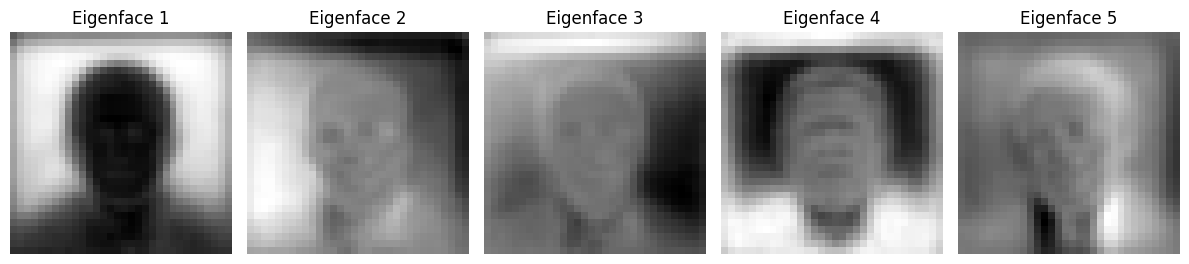

In [ ]:
plt.figure(figsize=(12, 3))
for i in range(5):
    eigenface = pca.components_[i].reshape(32, 32)
    plt.subplot(1, 5, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# **SUMMARY OF PART 1**

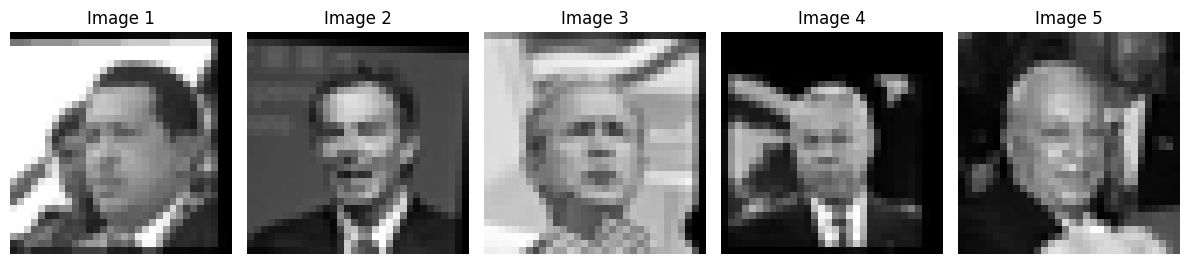

In [ ]:
plt.figure(figsize=(12, 3))
for i in range(5):
    original_img = faces_matrix[i].reshape(32, 32)  # These are already resized, but you may demonstrate 'original' here using your available images
    plt.subplot(1, 5, i + 1)
    plt.imshow(original_img, cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


2. GRAYSCALE AND RESIZE TO 32X32

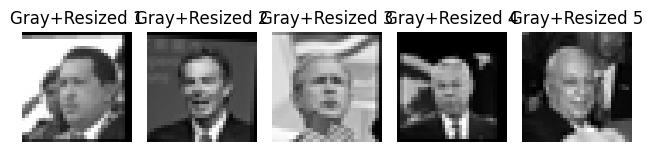

In [ ]:
# Pretend as if you do grayscale and resize; your dataset is already grayscale and 32x32, but for demonstration:
for i in range(5):
    img_array = faces_matrix[i].reshape(32, 32)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Gray+Resized {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


3. FLATTENED 1D VECTOR

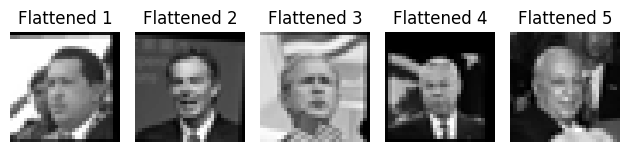

In [ ]:
for i in range(5):
    # Show the flattened vector as an image
    flat_vec = faces_matrix[i]            # Shape (1024,)
    reshaped = flat_vec.reshape(32, 32)   # Back to (32,32)
    plt.subplot(1, 5, i + 1)
    plt.imshow(reshaped, cmap='gray')
    plt.title(f"Flattened {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


4. STACK VECTORS AS NXR MATRIX [HEATMAP]

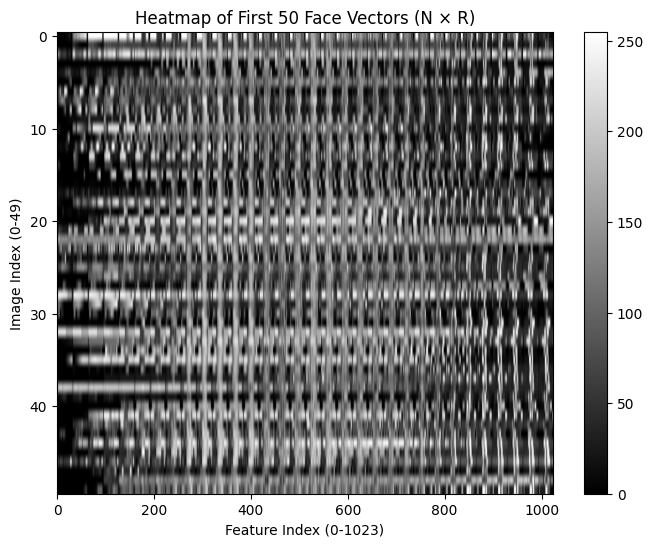

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(faces_matrix[:50], aspect='auto', cmap='gray')
plt.title('Heatmap of First 50 Face Vectors (N × R)')
plt.xlabel('Feature Index (0-1023)')
plt.ylabel('Image Index (0-49)')
plt.colorbar()
plt.show()


5. PCA WITH 95% VARIANCE

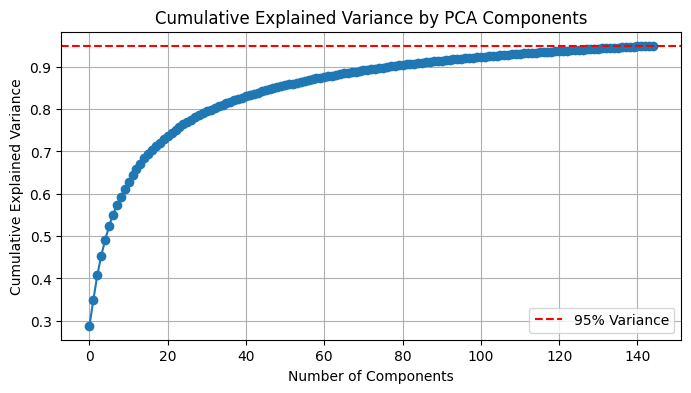

In [ ]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


6. TOP 5 EIGENFACES

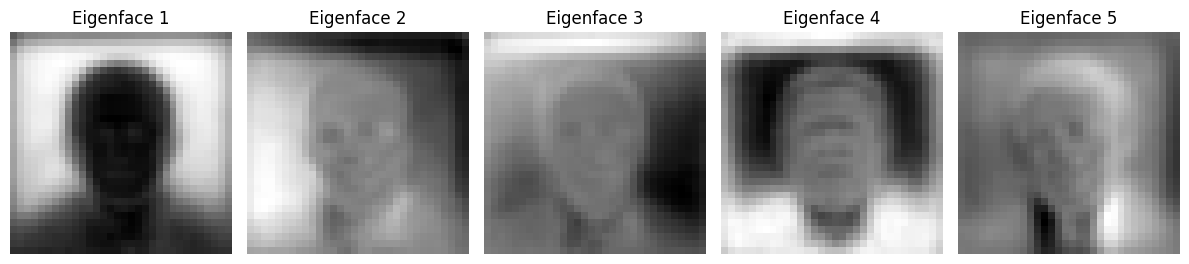

In [ ]:
plt.figure(figsize=(12, 3))
for i in range(5):
    eigenface = pca.components_[i].reshape(32, 32)
    plt.subplot(1, 5, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# **PART2**

## Step 7: Preprocess and Display Your Selfie

- Uploading a selfie
- The following code converts your selfie to grayscale, resizes to 32×32 pixels, and displays it.


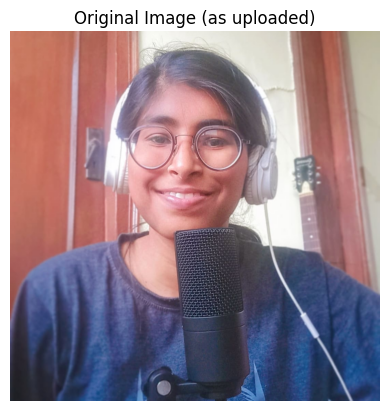

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Set filename to match your uploaded image (e.g., 'my_image.jpg')
original_img_path = 'selifie.jpg'  # Change this to your actual uploaded file name

# Load and display image as-is
original_img = Image.open(original_img_path)
plt.imshow(original_img)
plt.title("Original Image (as uploaded)")
plt.axis('off')
plt.show()


### Convert Uploaded Image to Grayscale and Resize

Now we process the image:
- Convert it to grayscale (removes color).
- Resize it to 32×32 pixels for uniformity.
- We’ll display the processed image.


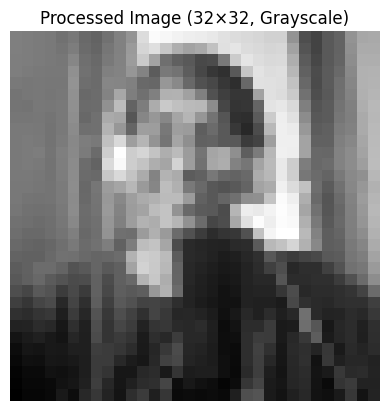

In [ ]:
# Use the original uploaded image
processed_img = Image.open(original_img_path).convert('L').resize((32, 32))

plt.imshow(processed_img, cmap='gray')
plt.title("Processed Image (32×32, Grayscale)")
plt.axis('off')
plt.show()


Shape of flattened vector: (1, 1024)


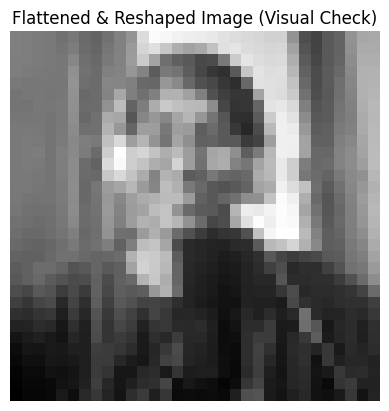

In [ ]:
# Flatten image to a 1D vector (shape: [1, 1024])
selfie_vector = np.array(processed_img).flatten().reshape(1, -1)
print(f"Shape of flattened vector: {selfie_vector.shape}")

# Visual check: reshape back and plot to confirm no info loss
plt.imshow(selfie_vector.reshape(32, 32), cmap='gray')
plt.title("Flattened & Reshaped Image (Visual Check)")
plt.axis('off')
plt.show()



Now we use PCA to:
- Project our selfie from pixel space onto the eigenface space (using learned components).
- Reconstruct it using only the most important eigenfaces retained in PCA.
- The result should look "blurred" and show which facial features are captured by the dataset.


In [ ]:
# Project your selfie onto the PCA (eigenface) space
selfie_pca = pca.transform(selfie_vector)

# Reconstruct your selfie from the PCA representation
selfie_recon = pca.inverse_transform(selfie_pca)
recon_img = selfie_recon.reshape(32, 32)


#### Compare Original and Reconstructed Selfie

Here we can see, side-by-side:
- Our fully processed 32×32 grayscale selfie (left).
- The reconstructed version using the top eigenfaces from PCA (right).

This comparison helps illustrate how much facial information is retained, compressed, or lost in the eigenface representation.


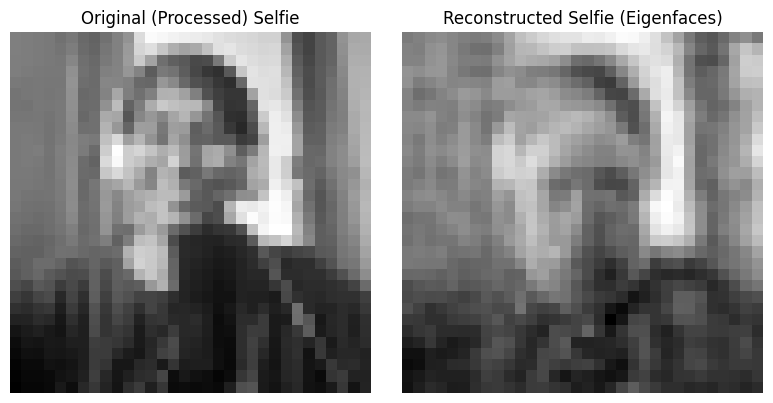

In [ ]:
plt.figure(figsize=(8, 4))

# Left: original processed selfie
plt.subplot(1, 2, 1)
plt.imshow(processed_img, cmap='gray')
plt.title("Original (Processed) Selfie")
plt.axis('off')

# Right: reconstructed selfie from PCA
plt.subplot(1, 2, 2)
plt.imshow(recon_img, cmap='gray')
plt.title("Reconstructed Selfie (Eigenfaces)")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Save Original (as uploaded)
original_img.save("selfie_original_uploaded.jpg")

# Save Processed (grayscale, 32x32)
processed_img.save("selfie_processed_32x32.jpg")

# Save Reconstructed (from PCA)
from PIL import Image
recon_img_uint8 = Image.fromarray(np.uint8(recon_img))
recon_img_uint8.save("selfie_reconstructed_pca.jpg")


C:\Users\any\AppData\Local\Temp\ipykernel_10216\3452297038.py:16: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  img_64 = pil_img.resize((64, 64), Image.BICUBIC)


Original feature size: 4096
Reduced feature size (eigenfaces): 430
Total variance explained: 0.95


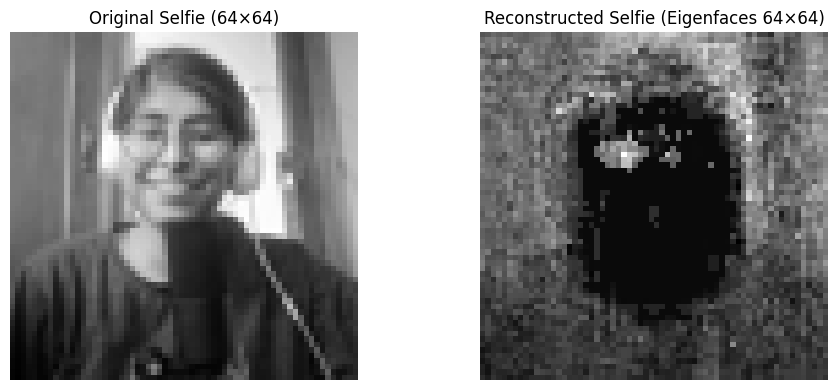

In [ ]:
from sklearn.datasets import fetch_lfw_people
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Load LFW dataset with largest available resolution ---
lfw_people = fetch_lfw_people(color=False, resize=1.0)
faces = lfw_people.images  # Shape: (N, 62, 47)
N = faces.shape[0]

# --- Resize each face to 64x64 ---
faces_matrix_64 = []
for img in faces:
    pil_img = Image.fromarray(np.uint8(img))
    img_64 = pil_img.resize((64, 64), Image.BICUBIC)
    faces_matrix_64.append(np.array(img_64))
faces_matrix_64 = np.array(faces_matrix_64)
faces_matrix_64_flat = faces_matrix_64.reshape(N, -1)  # Shape: (N, 4096)

# --- Load and preprocess selfie ---
selfie_filename = 'selifie.jpg'
selfie_img_64 = Image.open(selfie_filename).convert('L').resize((64, 64))
selfie_vector_64 = np.array(selfie_img_64).flatten().reshape(1, -1)

# --- Fit PCA with 95% variance ---
pca_64 = PCA(n_components=0.95, svd_solver='full')
faces_pca_64 = pca_64.fit_transform(faces_matrix_64_flat)

print(f"Original feature size: {faces_matrix_64_flat.shape[1]}")
print(f"Reduced feature size (eigenfaces): {pca_64.n_components_}")
print(f"Total variance explained: {np.sum(pca_64.explained_variance_ratio_):.2f}")

# --- Project selfie and reconstruct ---
selfie_proj_64 = pca_64.transform(selfie_vector_64)
selfie_recon_64 = pca_64.inverse_transform(selfie_proj_64)
recon_img_64 = selfie_recon_64.reshape(64, 64)

# --- Display comparison ---
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(selfie_img_64, cmap='gray')
plt.title("Original Selfie (64×64)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(recon_img_64, cmap='gray')
plt.title("Reconstructed Selfie (Eigenfaces 64×64)")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Save images ---
selfie_img_64.save("selfie_original_64x64.jpg")
Image.fromarray(np.clip(recon_img_64, 0, 255).astype('uint8')).save("selfie_reconstructed_64x64.jpg")


## *TEST 2*

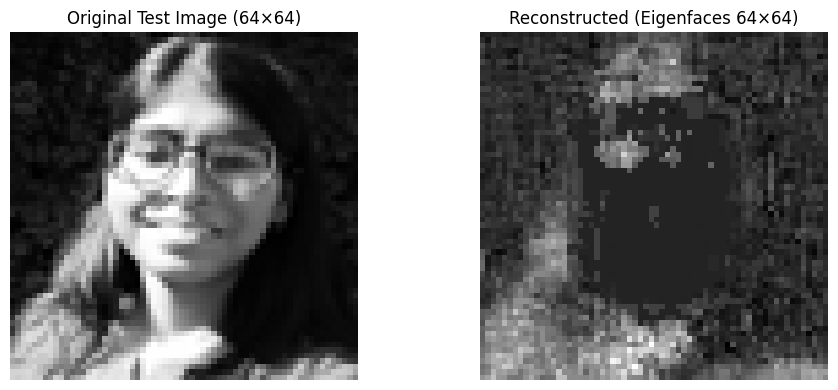

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# -- Step 1: Load and Preprocess Your New Image --
test_image_filename = 'tes2.jpg'  # <--- Change to your next image!
test_img_64 = Image.open(test_image_filename).convert('L').resize((64, 64))
test_vector_64 = np.array(test_img_64).flatten().reshape(1, -1)

# -- Step 2: Project and Reconstruct Using PCA Model --
test_proj_64 = pca_64.transform(test_vector_64)
test_recon_64 = pca_64.inverse_transform(test_proj_64)
test_recon_img_64 = test_recon_64.reshape(64, 64)

# -- Step 3: Display Results --
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.imshow(test_img_64, cmap='gray')
plt.title("Original Test Image (64×64)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(test_recon_img_64, cmap='gray')
plt.title("Reconstructed (Eigenfaces 64×64)")
plt.axis('off')
plt.tight_layout()
plt.show()

# -- Step 4: (Optional) Save Results --
test_img_64.save("test_original_64x64.jpg")
Image.fromarray(np.clip(test_recon_img_64, 0, 255).astype('uint8')).save("test_reconstructed_64x64.jpg")
